# Figures

Publication figures for the anti-diabetic peptide classifier in my dissertation.

Every figure is built from an exported CSV in `results/` or `screening/`, never by refitting a model.

Outputs go to `figures/` as a PNG at 400 dpi.

In [1]:
# shared style and save helper for every figure in this notebook

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Okabe-Ito palette, which stays distinguishable under colour-vision deficiency
# and in greyscale print. the second pair completes the set for the four docking roles
BLUE = "#0072B2"
VERMILLION = "#D55E00"
GREY = "#999999"
ORANGE = "#E69F00"
GREEN = "#009E73"

# matplotlib style settings for publication-quality figures and for consistency across figures
plt.rcParams.update({
    "figure.dpi": 110, # on-screen preview only
    "savefig.dpi": 400, # the exported png, high enough to print at column width
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})


def save_figure(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")

## Figure 4

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


a hard negative is nearest for 78.8% of positives, 75.1% on the embeddings alone, against 34.0% from class sizes


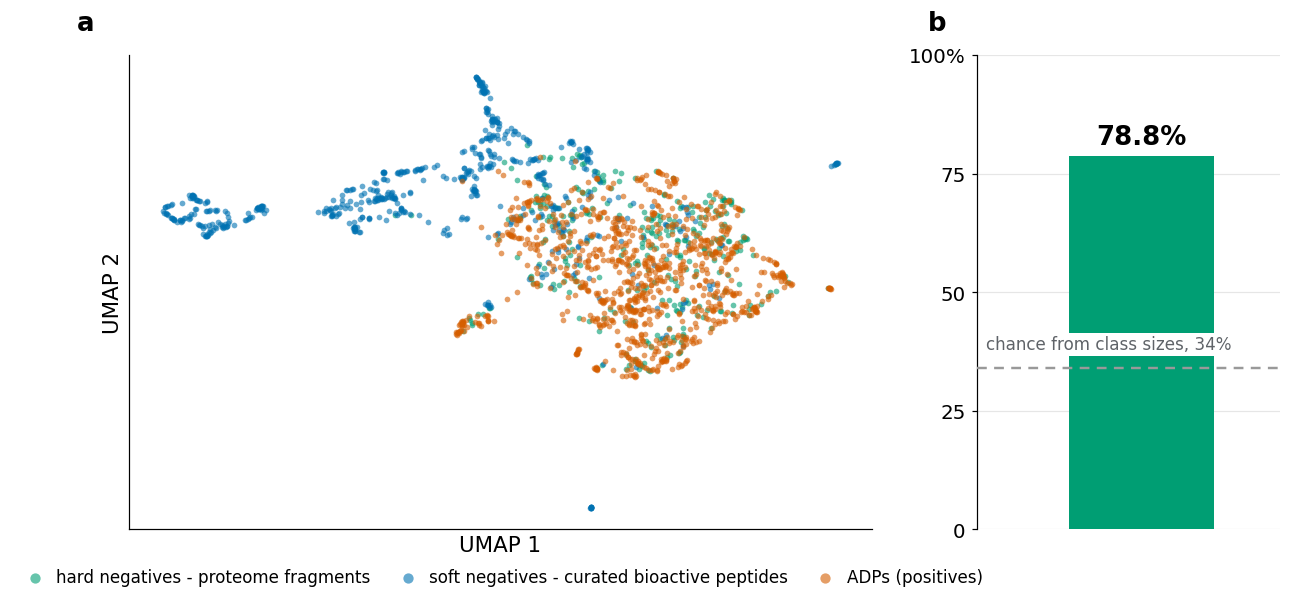

In [2]:
# for UMAP of the fused space
import numpy as np
from sklearn.neighbors import NearestNeighbors
import umap
from sklearn.preprocessing import normalize

# for reproducibility
SEED = 42

# load the fused vectors and the sequence labels and split to the negative types
d = np.load("fusion_vectors.npz", allow_pickle=True)
X, seqs, lab = d["X"], [str(s) for s in d["sequences"]], d["label"]

# NegType lives in the split rather than the npz, so the two negative classes can
# be told apart. anything not marked soft is a hard negative
split = pd.read_csv("data/dataset_split.csv", keep_default_na=False)
negtype = dict(zip(split.Sequence, split.NegType))
grp = np.array(["positive" if l == 1 else ("soft" if negtype.get(s) == "soft" else "hard")
                for s, l in zip(seqs, lab)])

# 2-D view of the space the fused-vector learners actually see
emb = umap.UMAP(n_neighbors=15, min_dist=0.10, metric="cosine",
                random_state=SEED).fit_transform(X)


def nearest_negative_is_hard(M):
    """Share of positives whose nearest negative is hard, in the cosine geometry of M."""
    # cosine rather than euclidean, matching the UMAP above. cosine compares
    # direction only, so the length signal carried in vector magnitude cannot leak
    # in. unit-length rows make euclidean neighbours rank the same as cosine
    Z = normalize(M)

    def nearest(g):
        # kneighbors returns distances then indices, so [0] takes the distances and
        # [:, 0] the one neighbour asked for. the result is one distance per positive
        knn = NearestNeighbors(n_neighbors=1).fit(Z[grp == g])
        return knn.kneighbors(Z[grp == "positive"])[0][:, 0]

    # elementwise, so each positive counts once for whichever negative type sits
    # closer to it. the mean of those booleans is the share that came out hard
    return 100 * np.mean(nearest("hard") < nearest("soft"))


# the control drops the seven descriptors, so a result that survives it is a
# property of the embeddings rather than of the hand engineered features
observed = nearest_negative_is_hard(X)
control = nearest_negative_is_hard(X[:, :1280])
chance = 100 * (grp == "hard").sum() / ((grp == "hard").sum() + (grp == "soft").sum())

# all three numbers appear in the Figure 4 caption and are saved nowhere else
print(f"a hard negative is nearest for {observed:.1f}% of positives, "
      f"{control:.1f}% on the embeddings alone, against {chance:.1f}% from class sizes")

fig, (ax, bx) = plt.subplots(1, 2, figsize=(13.5, 5.6),
                             gridspec_kw={"width_ratios": [2.45, 1], "wspace": 0.20})

# (a) hard is drawn first so the positives read on top of it
for g, colour, label in [("hard", GREEN, "hard negatives - proteome fragments"),
                         ("soft", BLUE, "soft negatives - curated bioactive peptides"),
                         ("positive", VERMILLION, "ADPs (positives)")]:

    # boolean mask for groups
    m = grp == g
    ax.scatter(emb[m, 0], emb[m, 1], s=14, c=colour, alpha=0.60, linewidths=0, label=label)

# UMAP axes carry no units, so no grid or ticks
ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3,
          markerscale=1.8, fontsize=11, handletextpad=0.3, columnspacing=1.2)

# (b) how often an ADP's closest non-ADP is a proteome fragment rather than a
# curated peptide, against the rate you would get picking a negative at random
bx.bar([0], [observed], width=0.44, color=GREEN, zorder=3)
bx.axhline(chance, color=GREY, lw=1.6, ls=(0, (4, 3)), zorder=4)
bx.text(0, observed + 2.5, f"{observed:.1f}%", ha="center", fontsize=17, fontweight="bold")

# the white box keeps the label readable where it crosses the bar
bx.text(-0.47, chance + 4.0, f"chance from class sizes, {chance:.0f}%",
        ha="left", fontsize=11, color="#5F6368",
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
bx.set_xlim(-0.5, 0.42)
bx.set_ylim(0, 100)
bx.set_xticks([])
bx.set_yticks([0, 25, 50, 75, 100])
bx.set_yticklabels(["0", "25", "50", "75", "100%"])
bx.grid(axis="x", visible=False)
bx.spines["bottom"].set_visible(False)

# panel letters go on last, in axes coordinates, so they track the boxes
# that gridspec produces. the offsets differ because transAxes is relative to each
# panel's own width and (a) is 2.45 times wider than (b)
for lab, a, dx in zip("ab", (ax, bx), (-0.07, -0.16)):
    a.text(dx, 1.04, lab, transform=a.transAxes, fontsize=17,
           fontweight="bold", va="bottom", ha="left")

save_figure(fig, "figure_4_negative_space")

Figure 4. Hard negatives sit closer to the ADPs than the curated peptides do. (a) UMAP of the 1,287-dimensional fused space (n_neighbors = 15, min_dist = 0.10, cosine metric, seed 42). Soft negatives form several compact clusters largely separate from the ADPs, whereas hard negatives are spread throughout it. (b) A hard negative is the nearest negative for 78.8% of positives against the 34.0% expected from class sizes. The dashed line marks that chance rate. The same test on the 1,280-dimensional embeddings alone gives 75.1%, so the effect is not an artefact of the seven descriptors.

## Figure 6

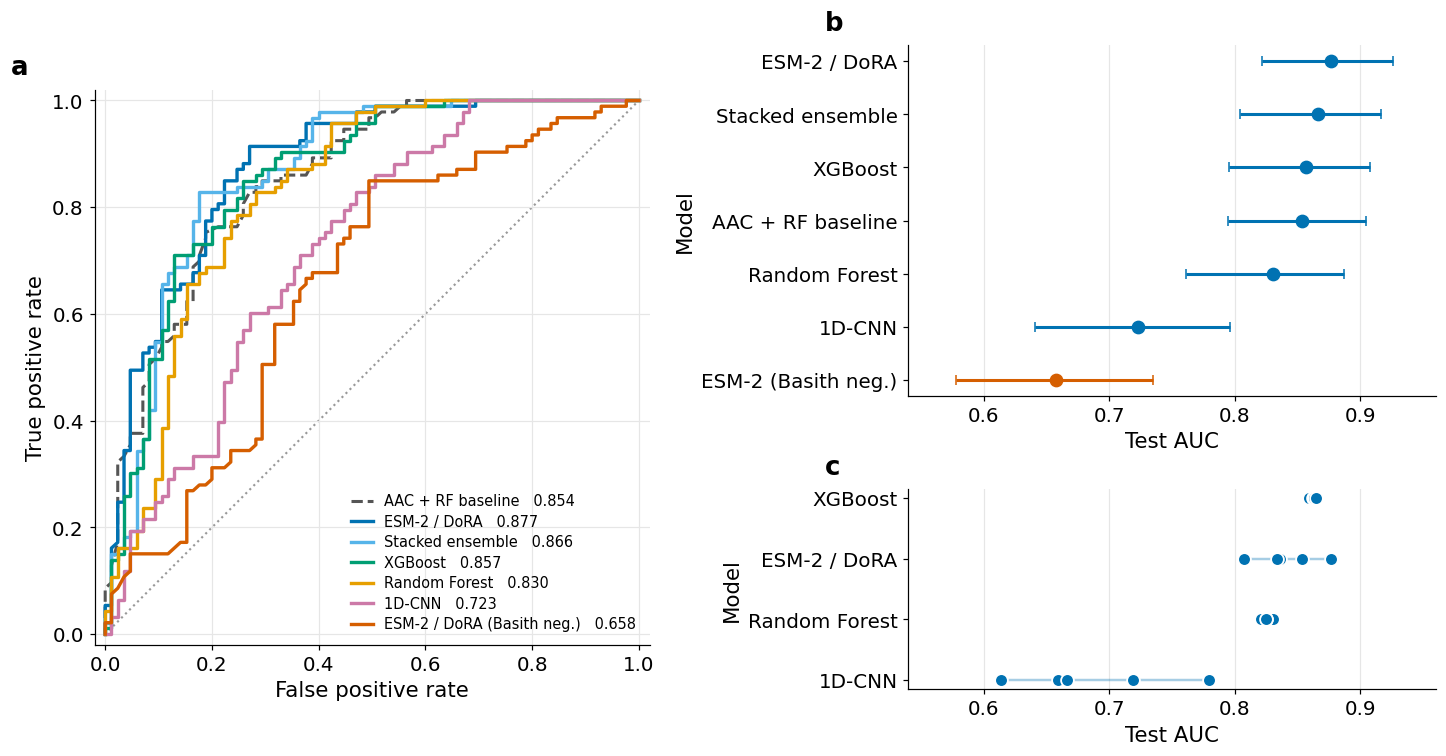

In [3]:
# for the ROC panel and the two summary panels
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# the two Okabe-Ito colours cell 1 does not name, so all six models stay distinguishable
SKY = "#56B4E9"
PURPLE = "#CC79A7"

# every model, with the npz and the key its test predictions live under
MODELS = [("ESM-2 / DoRA", "predictions/esm2_dora_predictions.npz", "esm_test", BLUE),
          ("Stacked ensemble", "predictions/stack_predictions.npz", "stack_test", SKY),
          ("XGBoost", "predictions/base_tree_predictions.npz", "xgb_test", GREEN),
          ("Random Forest", "predictions/base_tree_predictions.npz", "rf_test", ORANGE),
          ("1D-CNN", "predictions/base_cnn_predictions.npz", "cnn_test", PURPLE),
          ("ESM-2 / DoRA (Basith neg.)",
           "predictions/esm2_dora_basith_predictions.npz", "esm_test", VERMILLION)]

# y is loaded once so the assert can fire. the ablation model was fitted on a different
# training set and its predictions are the same length, so a mismatch would pass silently
y = np.load(MODELS[0][1], allow_pickle=True)["y_test"].astype(int)
curves = []
for name, path, key, colour in MODELS:
    d = np.load(path, allow_pickle=True)
    assert np.array_equal(d["y_test"].astype(int), y), f"{name} scored on a different test set"
    curves.append((name, roc_auc_score(y, d[key].astype(float)),
                   roc_curve(y, d[key].astype(float)), colour))

# the baseline is drawn apart from the rest, dashed and grey, since it is the floor the
# four learners are measured against rather than one of them
base = np.load("predictions/aac_baseline_predictions.npz", allow_pickle=True)
p_base = base["aac_test"].astype(float)
auc_base = roc_auc_score(y, p_base)
fpr_base, tpr_base, _ = roc_curve(y, p_base)

# tuned rows are dropped because every result in the report comes from the fixed
# configurations, the Optuna values being a tuning check only (Table 2)
ci = pd.read_csv("results/phase4_1_metrics_ci.csv")
ci = ci[~ci.model.str.contains("tuned")].sort_values("AUC").reset_index(drop=True)
SHORT = {"ESM-2 / DoRA (Basith negatives)": "ESM-2 (Basith neg.)",
         "AAC + RF (baseline)": "AAC + RF baseline"}
ci["short"] = ci.model.map(lambda m: SHORT.get(m, m))

st = pd.read_csv("results/phase4_2_seed_stability.csv")
st["label"] = st.model.map({"esm2": "ESM-2 / DoRA", "xgb": "XGBoost",
                            "rf": "Random Forest", "cnn": "1D-CNN"})
st = st.sort_values("mean_auc").reset_index(drop=True)

fig = plt.figure(figsize=(14.6, 7.6))

# add grid spec so the ROC can span both rows and the two summary panels share an x-axis
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.95], height_ratios=[7, 4],
                      wspace=0.30, hspace=0.34)
ax = fig.add_subplot(gs[:, 0]) # the ROC spans both rows
bx = fig.add_subplot(gs[0, 1])
cx = fig.add_subplot(gs[1, 1], sharex=bx) # shared x, so b and c read on one scale

# (a) ROC curves, sorted by AUC so the legend is the ranking
ax.plot([0, 1], [0, 1], ls=":", lw=1.4, color=GREY, zorder=1)
ax.plot(fpr_base, tpr_base, ls="--", lw=2.0, color="#555555", zorder=2,
        label=f"AAC + RF baseline   {auc_base:.3f}")
for name, auc, (fpr, tpr, _), colour in sorted(curves, key=lambda c: -c[1]):
    ax.plot(fpr, tpr, color=colour, lw=2.2, zorder=3, label=f"{name}   {auc:.3f}")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02); ax.set_aspect("equal")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=9.5, handlelength=1.5, labelspacing=0.38)

# (b) test AUC with its bootstrap interval, the ablation picked out in vermillion
for i, r in ci.iterrows():
    colour = VERMILLION if "Basith" in r.model else BLUE
    bx.errorbar(r.AUC, i, xerr=[[r.AUC - r.AUC_lo], [r.AUC_hi - r.AUC]], fmt="o", ms=8,
                color=colour, ecolor=colour, elinewidth=2, capsize=3.5, zorder=3)
bx.set_yticks(range(len(ci)), ci.short)
bx.set_ylabel("Model")
bx.grid(axis="y", visible=False) # horizontal gridlines would read as error bars
bx.set_xlabel("Test AUC")
bx.tick_params(labelbottom=True) # sharex hides these by default

# (c) the five seed fits per learner drawn individually, so the spread is visible rather
# than summarised into a mean and an SD
for i, r in st.iterrows():
    v = [float(x) for x in r.per_seed_auc.split(",")]
    cx.plot([min(v), max(v)], [i, i], color=BLUE, lw=1.6, alpha=0.35, zorder=2)
    cx.scatter(v, [i] * len(v), s=70, color=BLUE, edgecolor="white", linewidth=1.2, zorder=3)
cx.set_yticks(range(len(st)), st.label)
cx.set_ylabel("Model")
cx.grid(axis="y", visible=False)
cx.set_xlabel("Test AUC")

# sharex means this sets the range for b as well, so it has to hold b's widest interval,
# 0.578 on the ablation to 0.926 on ESM-2. every seed fit falls inside it too
cx.set_xlim(0.54, 0.96)

# the right-hand column crowds the ROC legend at this width, so both panels shift across
# together rather than reflowing the gridspec
for a in (bx, cx):
    p = a.get_position()
    a.set_position([p.x0 + 0.06, p.y0, p.width, p.height])

# panel letters placed off each axes' own box, so they follow if the layout moves
for lab, a in zip("abc", (ax, bx, cx)):
    p = a.get_position()
    fig.text(p.x0 - 0.052, p.y1 + 0.018, lab, fontsize=17, fontweight="bold")

save_figure(fig, "figure_6_model_comparison")
plt.show()

## Figure 3

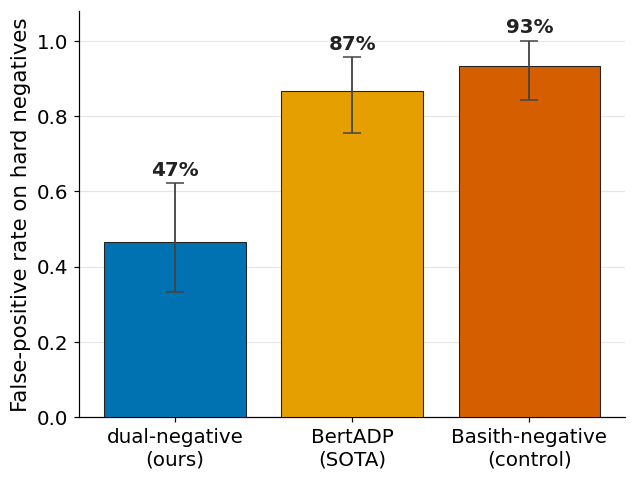

In [4]:
# --- hard-negative FPR, three models on the matched 45 ---
f = pd.read_csv("benchmark/hardneg_fpr.csv").set_index("model")
ORDER  = ["dual-neg ESM-2", "BertADP", "Basith-neg ESM-2"]
COLOUR = {"dual-neg ESM-2": BLUE, "BertADP": ORANGE, "Basith-neg ESM-2": VERMILLION}
LABEL  = {"dual-neg ESM-2": "dual-negative\n(ours)", "BertADP": "BertADP\n(SOTA)",
          "Basith-neg ESM-2": "Basith-negative\n(control)"}

fpr = [f.loc[m, "FPR"] for m in ORDER]
lo  = [f.loc[m, "CI_low"] for m in ORDER]
hi  = [f.loc[m, "CI_high"] for m in ORDER]
err = [[a - b for a, b in zip(fpr, lo)], [a - b for a, b in zip(hi, fpr)]]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.bar(range(3), fpr, yerr=err, capsize=6, color=[COLOUR[m] for m in ORDER],
       edgecolor="#222222", linewidth=0.7, zorder=3,
       error_kw=dict(ecolor="#444444", lw=1.2))
for i, (v, h) in enumerate(zip(fpr, hi)):
    ax.annotate(f"{v*100:.0f}%", (i, h), xytext=(0, 5), textcoords="offset points",
                ha="center", fontweight="bold", color="#222222")

ax.set_xticks(range(3)); ax.set_xticklabels([LABEL[m] for m in ORDER])
ax.set_ylabel("False-positive rate on hard negatives")
ax.set_ylim(0, 1.08); ax.xaxis.grid(False); ax.set_axisbelow(True)
save_figure(fig, "figure_hardneg_fpr")

## Figure n

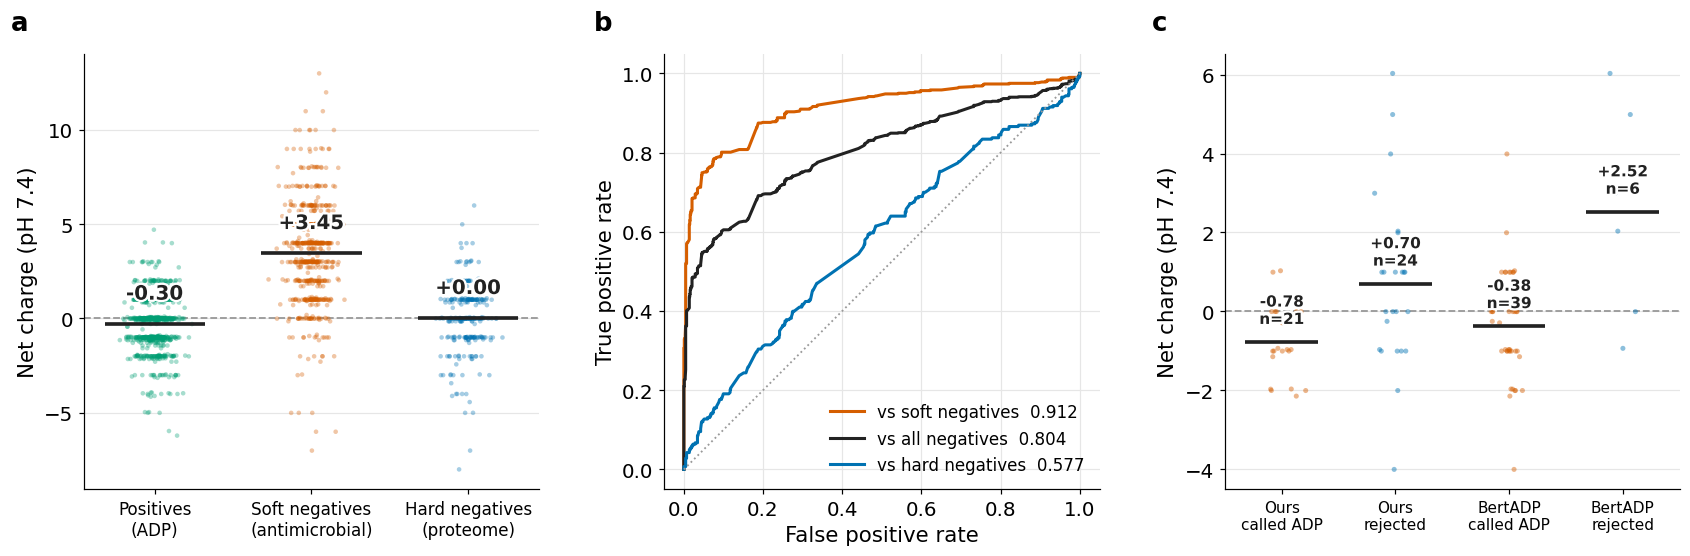

In [5]:
# net charge as a learnable shortcut in the negative class
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.patheffects as pe
import numpy as np

HALO = [pe.withStroke(linewidth=3, foreground="white")]

# charge as the models see it: descriptor 0 of the fused vector, in split-file row order
fz = np.load("fusion_vectors.npz", allow_pickle=True)
names = [str(s) for s in fz["descriptor_names"]]
split = pd.read_csv("data/dataset_split.csv", keep_default_na=False)
split["charge"] = fz["descriptors_raw"][:, names.index("net_charge_pH7.4")].astype(float)
assert [str(s) for s in fz["sequences"]] == split.Sequence.tolist(), "fusion rows misaligned"

tr = split[split.Split == "train"]
GROUPS = [("Positives\n(ADP)", tr[tr.Label == 1], GREEN),
          ("Soft negatives\n(antimicrobial)", tr[(tr.Label == 0) & (tr.NegType == "soft")], VERMILLION),
          ("Hard negatives\n(proteome)", tr[(tr.Label == 0) & (tr.NegType == "hard")], BLUE)]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
rng = np.random.default_rng(42)

# (a) where the charge sits in each training class
ax = axes[0]
for i, (label, g, colour) in enumerate(GROUPS):
    ax.scatter(i + rng.normal(0, 0.075, len(g)), g.charge, s=9, color=colour,
               alpha=0.35, edgecolor="none", zorder=2)
    ax.hlines(g.charge.mean(), i - 0.32, i + 0.32, color="#222222", lw=2.4, zorder=4)
    ax.annotate(f"{g.charge.mean():+.2f}", (i, g.charge.mean()), xytext=(0, 16),
                textcoords="offset points", ha="center", fontweight="bold",
                color="#222222", zorder=5, path_effects=HALO)
ax.axhline(0, color=GREY, ls="--", lw=1.2, zorder=1)
ax.set_xticks(range(3)); ax.set_xticklabels([g[0] for g in GROUPS], fontsize=11)
ax.set_ylabel("Net charge (pH 7.4)")
ax.xaxis.grid(False); ax.set_axisbelow(True)

# (b) charge alone as a classifier of the training labels
ax = axes[1]
CURVES = [("vs soft negatives", tr[(tr.Label == 1) | (tr.NegType == "soft")], VERMILLION),
          ("vs all negatives", tr, "#222222"),
          ("vs hard negatives", tr[(tr.Label == 1) | (tr.NegType == "hard")], BLUE)]
for label, sub, colour in CURVES:
    yneg = (sub.Label == 0).astype(int)
    fpr, tpr, _ = roc_curve(yneg, sub.charge)
    ax.plot(fpr, tpr, color=colour, label=f"{label}  {roc_auc_score(yneg, sub.charge):.3f}")
ax.plot([0, 1], [0, 1], ls=":", color=GREY, lw=1.2)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=11); ax.set_aspect("equal")

# (c) the rule surfacing in two independently trained models
ax = axes[2]
z = np.load("predictions/esm2_dora_predictions.npz", allow_pickle=True)
p = z["esm_test"].astype(float)
test = split[split.Split == "test"].reset_index(drop=True)
assert [str(s) for s in z["sequences"]][-len(p):] == test.Sequence.tolist(), "test rows misaligned"
test = test.assign(p=p)
ours = test[(test.Label == 0) & (test.NegType == "hard")]

bert = pd.read_csv("benchmark/bertadp_hardneg_all_pred.csv", keep_default_na=False)
bert = bert.merge(split[["Sequence", "charge", "Split"]], on="Sequence", how="left")
assert bert.charge.notna().all(), "BertADP peptides missing a charge"
# restrict to the same hard negatives our model is scored on, so the two n's are comparable.
# drop this line to show BertADP on all splits, but then say in the caption that the panel
# shows the direction of the charge rule, not comparable false-positive rates.
bert = bert[bert.Split == "test"]

COLS = [("Ours\ncalled ADP", ours.charge[ours.p > 0.5], VERMILLION),
        ("Ours\nrejected", ours.charge[ours.p <= 0.5], BLUE),
        ("BertADP\ncalled ADP", bert.charge[bert.Prediction == 1], VERMILLION),
        ("BertADP\nrejected", bert.charge[bert.Prediction == 0], BLUE)]
for i, (label, vals, colour) in enumerate(COLS):
    ax.scatter(i + rng.normal(0, 0.075, len(vals)), vals, s=11, color=colour,
               alpha=0.45, edgecolor="none", zorder=2)
    ax.hlines(vals.mean(), i - 0.32, i + 0.32, color="#222222", lw=2.4, zorder=4)
    ax.annotate(f"{vals.mean():+.2f}\nn={len(vals)}", (i, vals.mean()), xytext=(0, 12),
                textcoords="offset points", ha="center", fontsize=10, fontweight="bold",
                color="#222222", zorder=5, path_effects=HALO)
ax.axhline(0, color=GREY, ls="--", lw=1.2, zorder=1)
ax.set_xticks(range(4)); ax.set_xticklabels([c[0] for c in COLS], fontsize=10)
ax.set_ylabel("Net charge (pH 7.4)")
ax.xaxis.grid(False); ax.set_axisbelow(True)

# cross-check every drawn number against the exported table
src = pd.read_csv("results/phase6_5_charge_source.csv").set_index("quantity")["value"]
assert abs(roc_auc_score((tr.Label == 0).astype(int), tr.charge)
           - src["train_charge_auc_positives_vs_all_negatives"]) < 5e-4, "AUC drift vs phase6.5"
assert abs(ours.charge[ours.p > 0.5].mean()
           - src["test_hardneg_mean_charge_false_positive"]) < 5e-3, "FP charge drift vs phase6.5"

fig.tight_layout(w_pad=2.2)

# panel labels go on last, in axes coordinates, so they track the boxes tight_layout
# and set_aspect("equal") actually produce rather than the pre-layout positions
for lab, a in zip("abc", axes):
    a.text(-0.16, 1.04, lab, transform=a.transAxes, fontsize=17,
           fontweight="bold", va="bottom", ha="left")

save_figure(fig, "figure_charge_shortcut")

## Figure 4. Consensus reliability diagram

Sources `screening/consensus_calibration.csv`, the per-bin table written by Phase 5.0.

Point area is proportional to the number of out-of-fold peptides in each bin, so the eye weights
the bins the way the ECE weights them. The dotted line marks the 0.90 discovery threshold applied
in Phase 5.3. ECE is recomputed here from the per-bin table and cross-checked against the value
Phase 5.0 persisted, so a mismatch between the two files fails the cell rather than passing quietly.

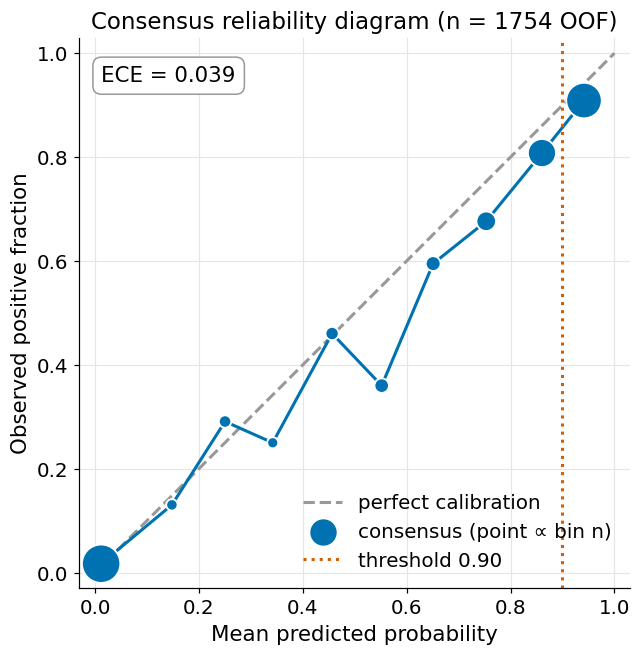

In [6]:
DISCOVERY_THRESHOLD = 0.90 # the cutoff applied in phase5.3, not the 0.87 the sweep permits

rel = pd.read_csv("screening/consensus_calibration.csv")

# ECE is the bin-count-weighted mean gap, recoverable from the exported table alone
ece = ((rel.n / rel.n.sum()) * (rel.mean_pred - rel.obs_pos).abs()).sum()
n_oof = int(rel.n.sum())

# cross-check against the value phase5.0 wrote
summary = pd.read_csv("results/phase5_0_calibration_summary.csv").set_index("quantity")["value"]
assert abs(ece - float(summary["ece_consensus_oof"])) < 5e-4, "ECE drift between table and summary"

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], ls="--", color=GREY, label="perfect calibration")
ax.plot(rel.mean_pred, rel.obs_pos, color=BLUE, zorder=2)
ax.scatter(rel.mean_pred, rel.obs_pos, s=1.2 * rel.n, color=BLUE, edgecolor="white",
           linewidth=1.2, zorder=3, label="consensus (point \u221d bin n)")
ax.axvline(DISCOVERY_THRESHOLD, color=VERMILLION, ls=":",
           label=f"threshold {DISCOVERY_THRESHOLD:.2f}")

ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.set_aspect("equal")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive fraction")
ax.set_title(f"Consensus reliability diagram (n = {n_oof} OOF)")
ax.annotate(f"ECE = {ece:.3f}", xy=(0.04, 0.92), xycoords="axes fraction", fontsize=14,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=GREY))
ax.legend(loc="lower right")

save_figure(fig, "figure_4_consensus_calibration")
plt.show()

## Figure 5

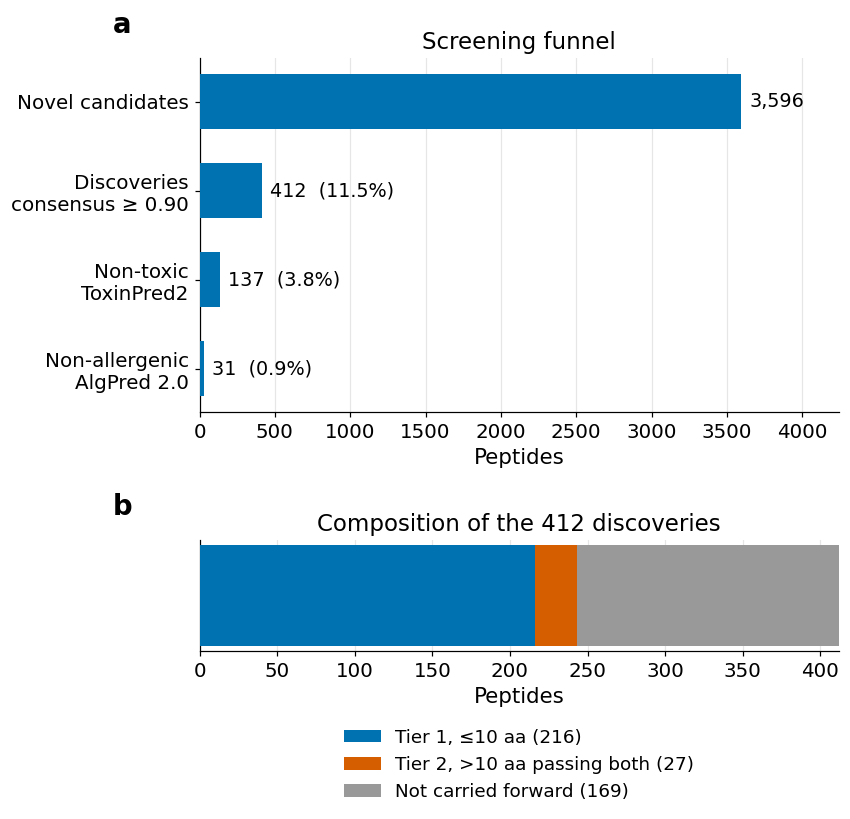

In [7]:
f = pd.read_csv("results/phase5_5_screening_funnel.csv").set_index("stage")["n"]

stages = [("Novel candidates", "novel_candidates"),
          ("Discoveries\nconsensus \u2265 0.90", "discoveries"),
          ("Non-toxic\nToxinPred2", "non_toxic"),
          ("Non-allergenic\nAlgPred 2.0", "non_toxic_non_allergen")]
labels, vals = [s[0] for s in stages], [int(f[s[1]]) for s in stages]

fig, (ax, bx) = plt.subplots(2, 1, figsize=(7.5, 7),
                             gridspec_kw={"height_ratios": [3.2, 1], "hspace": 0.55})

y = range(len(vals))
ax.barh(list(y), vals, color=BLUE, height=0.62, zorder=3)
ax.set_yticks(list(y), labels)
ax.invert_yaxis()
ax.set_xlim(0, max(vals) * 1.18)
ax.set_xlabel("Peptides")
ax.set_title("Screening funnel")
ax.grid(axis="y", visible=False)
for i, v in zip(y, vals):
    pct = 100 * v / vals[0]
    ax.text(v + max(vals) * 0.015, i, f"{v:,}" + (f"  ({pct:.1f}%)" if i else ""),
            va="center", fontsize=12.5)

# the tiers re-partition the discoveries, they do not continue the funnel
t1, t2 = int(f["tier1"]), int(f["tier2"])
rest = int(f["discoveries"]) - t1 - t2
segs = [(f"Tier 1, \u226410 aa ({t1})", t1, BLUE),
        (f"Tier 2, >10 aa passing both ({t2})", t2, VERMILLION),
        (f"Not carried forward ({rest})", rest, GREY)]
left = 0
for lab, v, c in segs:
    bx.barh([0], [v], left=left, color=c, height=0.5, label=lab, zorder=3)
    left += v
bx.set_yticks([])
bx.set_xlim(0, int(f["discoveries"]))
bx.set_xlabel("Peptides")
bx.set_title(f"Composition of the {int(f['discoveries'])} discoveries")
bx.grid(axis="y", visible=False)
bx.legend(loc="upper center", bbox_to_anchor=(0.5, -0.55), fontsize=12)
# panel letters, referenced as Figure 5a and 5b in the text
for lab, a in zip("ab", (ax, bx)):
    fig.text(0.02, a.get_position().y1 + 0.025, lab, fontsize=18, fontweight="bold", va="bottom")

save_figure(fig, "figure_5_screening_funnel")
plt.show()

## Figure 6. Docking energetics of the net-charge artefact

Sources `results/phase5_5_docking.csv`, written by `phase5.5_docking_parse.py`.

Panel a ranks the eight docked peptides by how much of their favourable HADDOCK score comes from electrostatics, so the three cationic decoys separate from the leads and controls by sort order
alone. Panel b plots the two energies behind that split. Genuine binders sit left of the dashed line, burying surface favourably. the decoys sit right of it with large electrostatics, scoring
well without desolvating. Identity is carried by colour and marker shape together, never colour alone and both long Tier-2 sequences are labelled by candidate ID.

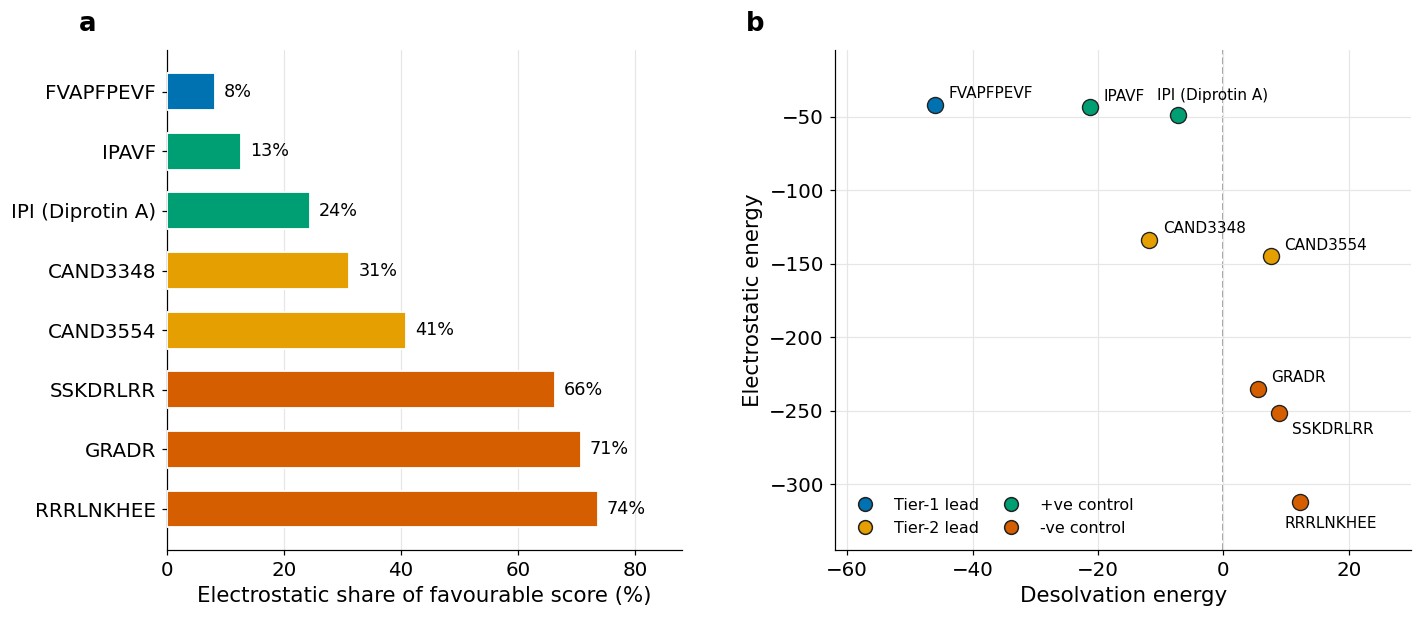

In [8]:
from matplotlib.lines import Line2D

COLOUR = {"Tier-1 lead": BLUE, "Tier-2 lead": ORANGE,
          "+ve control": GREEN, "-ve control": VERMILLION}
ORDER = ["Tier-1 lead", "Tier-2 lead", "+ve control", "-ve control"]

d = pd.read_csv("results/phase5_5_docking.csv")
man = pd.read_csv("docking/docking_manifest.csv")
nm = dict(zip(man.sequence, man.peptide_id.str.replace(r"^(LEAD_T\d_|POS_|NEG_)", "", regex=True)))
d["label"] = [s if len(s) <= 10 else nm.get(s, s[:8] + "\u2026") for s in d.peptide]
d.loc[d.peptide == "IPI", "label"] = "IPI (Diprotin A)"

fig, (ax, bx) = plt.subplots(1, 2, figsize=(14.6, 5.9),
                             gridspec_kw={"width_ratios": [1, 1.12], "wspace": 0.28})

# (a) share of the favourable score carried by charge, sorted so the decoys group at the bottom
s = d.sort_values("elec_pct_of_favourable")
y = range(len(s))
ax.barh(list(y), s.elec_pct_of_favourable, color=[COLOUR[r] for r in s.role],
        height=0.62, edgecolor="white", linewidth=1.2, zorder=3)
ax.set_yticks(list(y), s.label)
ax.invert_yaxis()
ax.set_xlim(0, 88)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Electrostatic share of favourable score (%)")
for i, v in zip(y, s.elec_pct_of_favourable):
    ax.text(v + 1.6, i, f"{v:.0f}%", va="center", fontsize=11.5)

# (b) the two energies behind the split. Offsets are per point, so no label overlaps a neighbour
bx.axvline(0, ls="--", lw=1.2, color=GREY, zorder=1)
OFFSET = {"FVAPFPEVF": (9, 4), "IPAVF": (9, 4), "IPI (Diprotin A)": (-14, 10),
          "CAND3348": (9, 4), "CAND3554": (9, 4),
          "GRADR": (9, 5), "SSKDRLRR": (9, -14), "RRRLNKHEE": (-10, -17)}
for r in d.itertuples():
    bx.scatter(r.desolv, r.elec, s=110, marker="o", c=COLOUR[r.role],
               edgecolors="#222222", linewidths=0.9, zorder=3)
    bx.annotate(r.label, (r.desolv, r.elec), xytext=OFFSET[r.label],
                textcoords="offset points", fontsize=10)
bx.set_xlabel("Desolvation energy")
bx.set_ylabel("Electrostatic energy")
bx.set_xlim(-62, 30)
bx.set_ylim(-345, -5)
bx.legend(handles=[Line2D([0], [0], marker="o", color="none", markerfacecolor=COLOUR[r],
                          markeredgecolor="#222222", markersize=9, label=r) for r in ORDER],
          loc="lower left", fontsize=10.5, ncol=2, columnspacing=1.0)

for lab, a in zip("ab", (ax, bx)):
    p = a.get_position()
    fig.text(p.x0 - 0.055, p.y1 + 0.03, lab, fontsize=17, fontweight="bold")

save_figure(fig, "figure_6_docking_charge")
plt.show()

## Figure 8

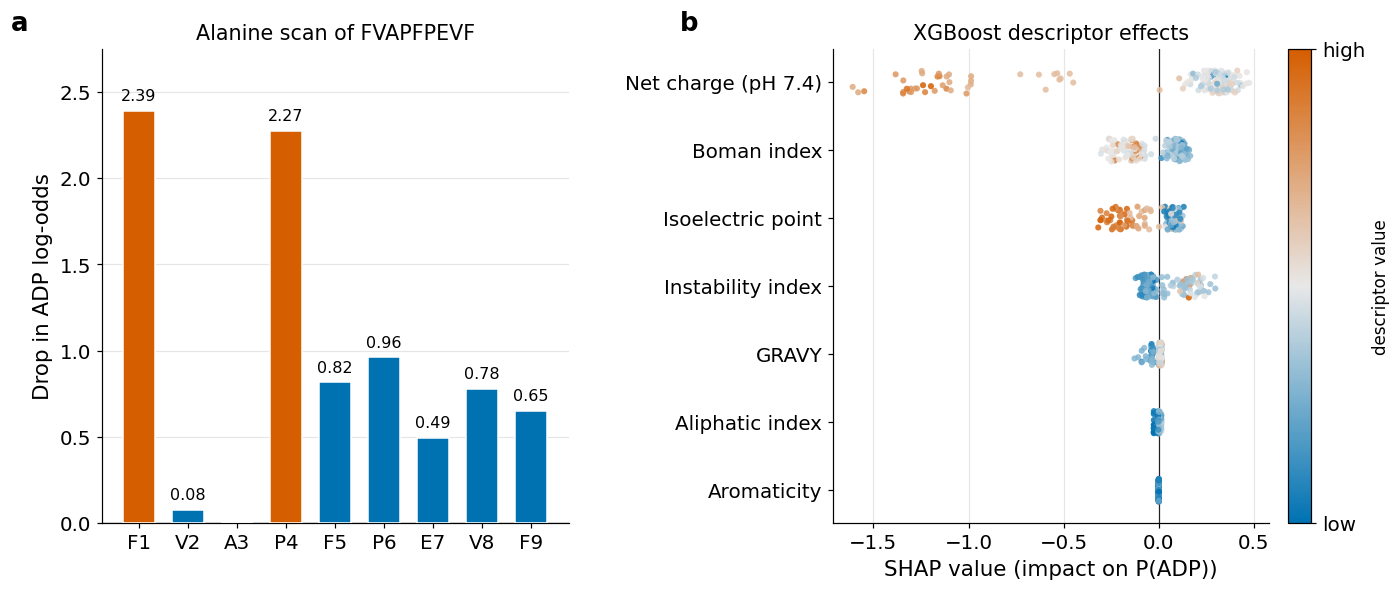

In [9]:
from matplotlib.colors import LinearSegmentedColormap

PRETTY = {"net_charge_pH7.4": "Net charge (pH 7.4)", "boman_index": "Boman index",
          "isoelectric_point": "Isoelectric point", "instability_index": "Instability index",
          "gravy_kd": "GRAVY", "aliphatic_index": "Aliphatic index",
          "aromaticity": "Aromaticity"}
CMAP = LinearSegmentedColormap.from_list("bwv", [BLUE, "#E8E8E8", VERMILLION])

a = pd.read_csv("results/phase5_6_alanine_scan.csv")
wt = float(a.wt_P_adp.iloc[0])
m = np.load("results/phase5_6_shap_matrix.npz", allow_pickle=True)
sv, val, names = m["shap_desc"], m["value_desc"], [str(x) for x in m["names"]]
share = float(pd.read_csv("results/phase5_6_shap_descriptors.csv")
              .query("model == 'xgb'").descriptor_share_of_total.iloc[0])
order = np.argsort(np.abs(sv).mean(0))

fig, (ax, bx) = plt.subplots(1, 2, figsize=(14.2, 5.6),
                             gridspec_kw={"width_ratios": [1, 1.16], "wspace": 0.40})

labels = [f"{r.wt}{r.position}" for r in a.itertuples()]
colours = [GREY if r.already_ala else (VERMILLION if r.delta_logodds > 2 else BLUE)
           for r in a.itertuples()]
ax.bar(labels, a.delta_logodds, color=colours, width=0.66,
       edgecolor="white", linewidth=1.0, zorder=3)
ax.axhline(0, color="#222222", lw=0.8)
ax.set_ylim(0, 2.75)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Drop in ADP log-odds")
ax.set_title("Alanine scan of FVAPFPEVF", fontsize=13.5)
for r in a.itertuples():
    if r.delta_logodds > 0.05:
        ax.text(r.position - 1, r.delta_logodds + 0.06, f"{r.delta_logodds:.2f}",
                ha="center", fontsize=10.5)

# beeswarm drawn by hand so it uses the notebook palette rather than shap's default
rng = np.random.default_rng(42)
for row, j in enumerate(order):
    v, s = val[:, j], sv[:, j]
    spread = np.ptp(v)
    bx.scatter(s, row + rng.uniform(-0.17, 0.17, len(s)),
               c=(v - v.min()) / (spread if spread else 1), cmap=CMAP,
               s=16, edgecolor="none", alpha=0.85, vmin=0, vmax=1, zorder=3)
bx.axvline(0, color="#222222", lw=0.8, zorder=2)
bx.set_yticks(range(len(order)), [PRETTY[names[j]] for j in order])
bx.grid(axis="y", visible=False)
bx.set_xlabel("SHAP value (impact on P(ADP))")
bx.set_title("XGBoost descriptor effects", fontsize=13.5)
sm = plt.cm.ScalarMappable(cmap=CMAP); sm.set_array([])

# colorbar for the SHAP beeswarm, with ticks at the ends of the colormap
cb = fig.colorbar(sm, ax=bx, pad=0.15, fraction=0.045, ticks=[0, 1])
cb.ax.set_yticklabels(["low", "high"])
cb.set_label("descriptor value", fontsize=11)
cb.ax.set_yticklabels(["low", "high"])
cb.set_label("descriptor value", fontsize=11)

for lab, axis in zip("ab", (ax, bx)):
    p = axis.get_position()
    fig.text(p.x0 - 0.058, p.y1 + 0.03, lab, fontsize=17, fontweight="bold")

# shift bx right by 0.04 in figure coordinates
shift = 0.04
p = bx.get_position()
bx.set_position([p.x0 + shift, p.y0, p.width, p.height])

save_figure(fig, "figure_8_interpretability")
plt.show()

## Figure S1

charged (K, R, E, D): 39.0% of total importance, against 20% if all twenty contributed equally
cationic (K, R) alone: 25.4%   |   ranks: K=1, R=2, E=3, D=6


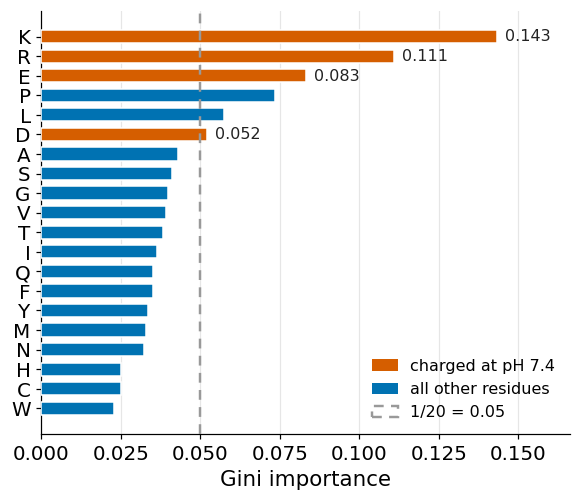

In [10]:
# ── Figure S1 — what the composition baseline actually learned ────────────────
# Gini importances exported by phase1.4_baselineRF.ipynb. Nothing is refitted here.
import numpy as np
from matplotlib.patches import Patch, Rectangle

CHARGED = set("KRED")     # net charge at pH 7.4; His is ~neutral and excluded

d   = np.load("predictions/aac_baseline_predictions.npz", allow_pickle=True)
imp = d["feature_importances"]
aa  = np.array([str(a) for a in d["feature_names"]])

order   = np.argsort(imp)[::-1]
imp, aa = imp[order], aa[order]
uniform = 1 / len(imp)

is_charged     = np.array([a in CHARGED for a in aa])
charged_share  = imp[is_charged].sum()
cationic_share = imp[[a in "KR" for a in aa]].sum()

print(f"charged (K, R, E, D): {charged_share:.1%} of total importance, "
      f"against {4 * uniform:.0%} if all twenty contributed equally")
print(f"cationic (K, R) alone: {cationic_share:.1%}   |   ranks: "
      + ", ".join(f"{a}={i+1}" for i, a in enumerate(aa) if a in CHARGED))

fig, ax = plt.subplots(figsize=(6.2, 5.0))
ax.set_axisbelow(True)

y = range(len(imp))
ax.barh(list(y), imp, height=0.68,
        color=np.where(is_charged, VERMILLION, BLUE),
        edgecolor="white", linewidth=1.0, zorder=3)
ax.invert_yaxis()

ax.axvline(uniform, color=GREY, lw=1.6, ls=(0, (4, 3)), zorder=4)

for i, (a, v) in enumerate(zip(aa, imp)):
    if a in CHARGED:
        ax.text(v + imp.max() * 0.018, i, f"{v:.3f}",
                va="center", fontsize=10.5, color="#222222")

ax.set_yticks(list(y), aa)
ax.set_xlim(0, imp.max() * 1.16)
ax.set_xlabel("Gini importance")
ax.grid(axis="y", visible=False)

ax.legend(handles=[Patch(facecolor=VERMILLION, label="charged at pH 7.4"),
                   Patch(facecolor=BLUE, label="all other residues"),
                   Rectangle((0, 0), 1, 1, fill=False, edgecolor=GREY, linewidth=1.6,
                             linestyle=(0, (4, 3)), label=f"1/20 = {uniform:.2f}")],
          loc="lower right", fontsize=10.5, handlelength=1.6)

save_figure(fig, "figS1_aac_importance")
plt.show()